In [7]:
!pip install pandas matplotlib seaborn scikit-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Shape: (200, 10)

First 5 rows:
   studytime  failures  absences internet sex Pstatus  age  G1  G2  G3
0          2         1         8       no   M       A   20   9   6   5
1          4         0        29       no   F       A   20  12  14  14
2          3         0        16       no   F       T   15  13  11  10
3          2         2        16       no   F       T   16   7   5   4
4          1         1        29      yes   M       A   15   8   7   7

Basic Stats:
        studytime    failures    absences         age          G1          G2  \
count  200.000000  200.000000  200.000000  200.000000  200.000000  200.000000   
mean     2.315000    0.635000   15.340000   17.980000   11.210000   10.785000   
std      0.995354    0.857585    8.449935    2.073911    3.267919    3.705052   
min      1.000000    0.000000    0.000000   15.000000    2.000000    0.000000   
25%      2.000000    0.000000    8.000000   16.000000    9.000000    8.000000   
50%      2.000000    0.000000   15.000000 

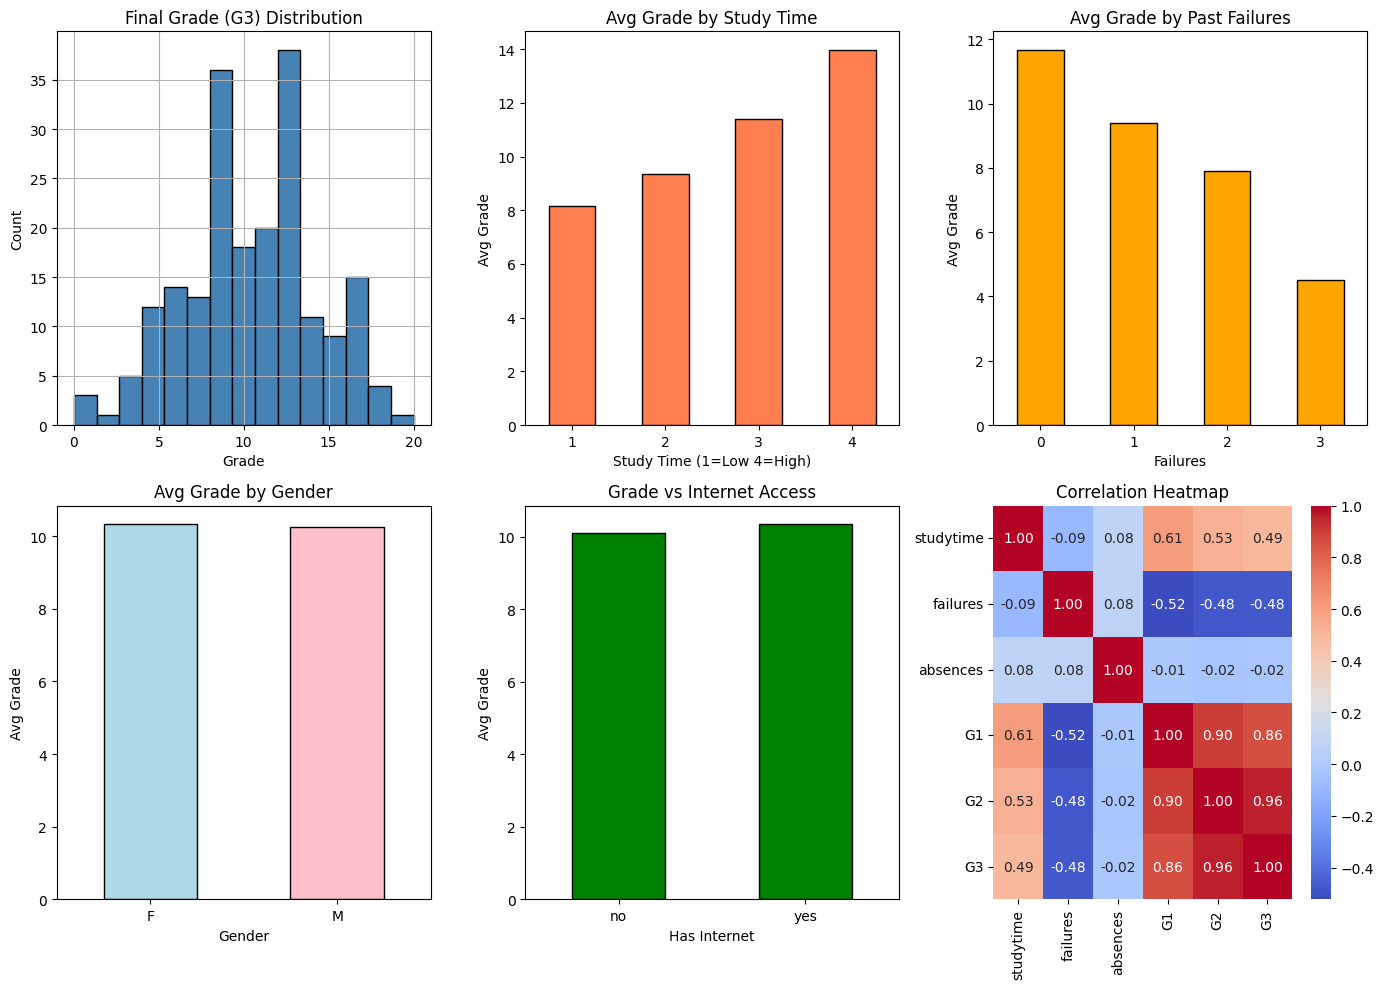


=== KEY FINDINGS ===
Total Students: 200
Average Final Grade: 10.28 / 20
Pass Rate (G3 >= 10): 58.0%
Correlation studytime→G3: 0.489
Correlation failures→G3:  -0.481
Avg grade with internet:   10.34
Avg grade without internet:10.10


In [8]:
# ============================================
# PROJECT 1: Student Performance Analysis
# SPPU Data Science Lab - PCC-255-CAI
# Dataset: Built-in (no download needed)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create dataset manually (UCI Student Performance data, simplified) ---
np.random.seed(42)
n = 200

data = {
    'studytime': np.random.choice([1,2,3,4], n, p=[0.2,0.4,0.25,0.15]),
    'failures':  np.random.choice([0,1,2,3], n, p=[0.6,0.25,0.1,0.05]),
    'absences':  np.random.randint(0, 30, n),
    'internet':  np.random.choice(['yes','no'], n, p=[0.7,0.3]),
    'sex':       np.random.choice(['M','F'], n),
    'Pstatus':   np.random.choice(['T','A'], n, p=[0.8,0.2]),
    'age':       np.random.randint(15, 22, n),
}

# Generate grades correlated with studytime and failures
G1 = (8 + data['studytime'] * 2 - data['failures'] * 2
      + np.random.normal(0, 2, n)).clip(0, 20).astype(int)
G2 = (G1 + np.random.normal(0, 1.5, n)).clip(0, 20).astype(int)
G3 = (G2 + np.random.normal(0, 1,   n)).clip(0, 20).astype(int)

data['G1'] = G1
data['G2'] = G2
data['G3'] = G3

df = pd.DataFrame(data)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic Stats:")
print(df.describe())
print("\nMissing Values:", df.isnull().sum().sum())

# --- Visualizations ---
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
df['G3'].hist(bins=15, color='steelblue', edgecolor='black')
plt.title('Final Grade (G3) Distribution')
plt.xlabel('Grade'); plt.ylabel('Count')

plt.subplot(2, 3, 2)
df.groupby('studytime')['G3'].mean().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Avg Grade by Study Time')
plt.xlabel('Study Time (1=Low 4=High)'); plt.ylabel('Avg Grade'); plt.xticks(rotation=0)

plt.subplot(2, 3, 3)
df.groupby('failures')['G3'].mean().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Avg Grade by Past Failures')
plt.xlabel('Failures'); plt.ylabel('Avg Grade'); plt.xticks(rotation=0)

plt.subplot(2, 3, 4)
df.groupby('sex')['G3'].mean().plot(kind='bar', color=['lightblue','pink'], edgecolor='black')
plt.title('Avg Grade by Gender')
plt.xlabel('Gender'); plt.ylabel('Avg Grade'); plt.xticks(rotation=0)

plt.subplot(2, 3, 5)
df.groupby('internet')['G3'].mean().plot(kind='bar', color='green', edgecolor='black')
plt.title('Grade vs Internet Access')
plt.xlabel('Has Internet'); plt.ylabel('Avg Grade'); plt.xticks(rotation=0)

plt.subplot(2, 3, 6)
cols = ['studytime','failures','absences','G1','G2','G3']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('student_analysis.png', dpi=100)
plt.show()

# --- Key Insights ---
print("\n=== KEY FINDINGS ===")
print(f"Total Students: {len(df)}")
print(f"Average Final Grade: {df['G3'].mean():.2f} / 20")
print(f"Pass Rate (G3 >= 10): {(df['G3'] >= 10).mean()*100:.1f}%")
print(f"Correlation studytime→G3: {df['studytime'].corr(df['G3']):.3f}")
print(f"Correlation failures→G3:  {df['failures'].corr(df['G3']):.3f}")
print(f"Avg grade with internet:   {df[df['internet']=='yes']['G3'].mean():.2f}")
print(f"Avg grade without internet:{df[df['internet']=='no']['G3'].mean():.2f}")